<a href="https://colab.research.google.com/github/sahilghogare/Machine-Learning-Experiments/blob/main/23102A0061_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Sahil Suresh Ghogare

Roll no.: 23102A0061

Branch/ Div: TE CMPN A

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fraud_test_preprocessed.csv to fraud_test_preprocessed.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
data = pd.read_csv("fraud_test_preprocessed.csv")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59054 entries, 0 to 59053
Columns: 270 entries, dist1 to isFraud
dtypes: float64(111), int64(159)
memory usage: 121.6 MB


In [ ]:
data.describe()

,dist1,dist2,C1,C2,C5,C6,C9,C10,C11,C12,...,p_r_domain_False,id_14_nan,id_34_nan,id_32_nan,os_nan,id_33_nan,addr2_87.0,card3_150.0,id_18_nan,isFraud
count,59054.000000,59054.000000,59054.000000,59054.000000,59054.000000,59054.000000,59054.000000,59054.000000,59054.000000,59054.000000,...,59054.000000,59054.000000,59054.000000,59054.000000,59054.000000,59054.000000,59054.000000,59054.000000,59054.000000,59054.000000
mean,0.490397,0.499825,0.515446,0.516821,0.296630,0.491655,0.495586,0.192259,0.508876,0.210925,...,0.848952,0.884766,0.885444,0.888069,0.888069,0.888069,0.887713,0.890575,0.929810,0.037474
std,0.192811,0.066376,0.264241,0.262936,0.396273,0.272804,0.325173,0.369604,0.243424,0.384212,...,0.358099,0.319306,0.318488,0.315285,0.315285,0.315285,0.315722,0.312175,0.255469,0.189922
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.490991,0.500501,0.268769,0.268268,0.000000,0.372372,0.000000,0.000000,0.333333,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
50%,0.490991,0.500501,0.268769,0.623123,0.000000,0.372372,0.506006,0.000000,0.333333,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
75%,0.490991,0.500501,0.758759,0.754254,0.736737,0.735736,0.765766,0.000000,0.739740,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,0.998231,0.998260,0.999788,0.999007,0.999416,0.997778,0.998318,0.997476,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
data.isnull().sum()

,0
dist1,0
dist2,0
C1,0
C2,0
C5,0
...,...
id_33_nan,0
addr2_87.0,0
card3_150.0,0
id_18_nan,0


**Separating features(X) and target(y)**

In [ ]:
X = data.drop("isFraud", axis=1) #features
y = data["isFraud"] #target

**Scaling features(X)**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Applying PCA**

In [ ]:
pca = PCA()
pca.fit(X_scaled)

PCA()

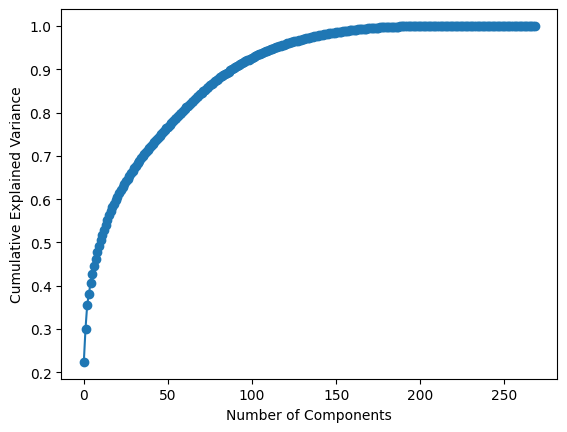

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

**Choosing Best number of components for PCA**

Components: 1  Accuracy: 0.9597832528998391
Components: 2  Accuracy: 0.9597832528998391
Components: 3  Accuracy: 0.9602912539158411
Components: 4  Accuracy: 0.9607145880958429
Components: 5  Accuracy: 0.9604605875878418

Accuracy dropped → stopping loop

Best components: 4
Best accuracy: 0.9607145880958429


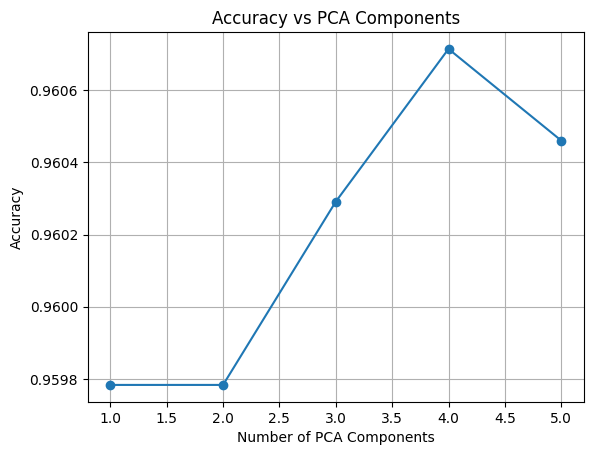

In [ ]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

best_acc = 0
best_n = 0

components = []
accuracies = []

for n in range(1, X.shape[1]+1):

    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X_scaled)

    X_train, X_test, y_train, y_test = train_test_split(
        X_pca, y, test_size=0.2, random_state=42
    )

    model = LogisticRegression(max_iter=500)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)

    print("Components:", n, " Accuracy:", acc)

    components.append(n)
    accuracies.append(acc)

    if acc < best_acc:
        print("\nAccuracy dropped → stopping loop")
        break

    best_acc = acc
    best_n = n

print("\nBest components:", best_n)
print("Best accuracy:", best_acc)


# PLOT GRAPH
plt.plot(components, accuracies, marker='o')
plt.xlabel("Number of PCA Components")
plt.ylabel("Accuracy")
plt.title("Accuracy vs PCA Components")
plt.grid(True)
plt.show()


**Applying PCA on selected best components**

In [ ]:
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)
print("New shape after PCA:", X_pca.shape)

New shape after PCA: (59054, 4)


**Training Model**

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X_pca,y,test_size=0.2,random_state=42
)

model=LogisticRegression(max_iter=500)
model.fit(X_train,y_train)

print(model.score(X_test,y_test))

0.9607145880958429
